In [1]:
import os
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.iolib.summary2 import summary_col
import patsy
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

In [2]:
FIGURE_DIR = "../output/figures/regression"
TABLE_DIR = "../output/tables"
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

def save_figure(filename_stem, directory=FIGURE_DIR):
    """Save the current matplotlib figure as pdf, png and svg."""
    for ext in ["pdf", "png", "svg"]:
        plt.savefig(f"{directory}/{filename_stem}.{ext}", dpi=300, bbox_inches="tight")

def save_latex_table(models, model_names, filename_stem, directory=TABLE_DIR, label_map=None,
                      regressor_order=None, fe_prefix='C(industry_fe', fe_label="Industry FE", **kwargs):

    def has_industry_fe(m):
        return "Yes" if any(name.startswith(fe_prefix) for name in m.model.exog_names) else "No"

    info_dict = {
        fe_label: has_industry_fe,
        "N":  lambda m: f"{int(m.nobs)}",
        "R2": lambda m: f"{m.rsquared:.3f}",
    }

    table = summary_col(
        models, stars=True, model_names=model_names,
        regressor_order=regressor_order or [],
        drop_omitted=True,
        info_dict=info_dict,
        **kwargs
    )
    tex = table.as_latex()
    if label_map:
        for var, label in sorted(label_map.items(), key=lambda kv: len(kv[0]), reverse=True):
            tex = tex.replace(var, label)
            tex = tex.replace(var.replace('_', r'\_'), label)
    with open(f"{directory}/{filename_stem}.tex", "w") as f:
        f.write(tex)
    return table

def save_latex_table(models, model_names, filename_stem, directory=TABLE_DIR, label_map=None, **kwargs):
    table = summary_col(
        models, stars=True, model_names=model_names,
        info_dict={"N": lambda m: f"{int(m.nobs)}", "R2": lambda m: f"{m.rsquared:.3f}"},
        **kwargs
    )
    tex = table.as_latex()
    if label_map:
        for var, label in sorted(label_map.items(), key=lambda kv: len(kv[0]), reverse=True):
            tex = tex.replace(var, label)
            tex = tex.replace(var.replace('_', r'\_'), label)
    with open(f"{directory}/{filename_stem}.tex", "w") as f:
        f.write(tex)
    return table

In [3]:
# Standardized data for the regressions themselves; raw data kept alongside
# for filters that need real integer values (e.g. n_companies == 1 )
data_path = "../output/data/merged_analysis_data_standardized.pkl"
raw_data_path = "../output/data/merged_analysis_data.pkl"

df = pd.read_pickle(data_path)
df_raw = pd.read_pickle(raw_data_path)

In [4]:
industry_codes = [
    "A","B","C","D","E","F","G","H","I","J","K","L","M","N","O","P","Q","R","S"
]
industry_bool_cols = [f"industry_{c}" for c in industry_codes]

df["industry_fe"] = df[industry_bool_cols].idxmax(axis=1).str.replace("industry_", "")
df["industry_fe"] = pd.Categorical(df["industry_fe"])

In [6]:
# --- Formula with industry FE ---
# with Q FE we get WPD industries
formula_rhs = """
    loc_work_gaussian_opening
    + productivity
    + n_companies
    + entropy
    + C(industry_fe, Treatment("G"))
    + distance_to_deak
    + work_cluster_1
    + work_cluster_0
    + arpu_high_ratio_open
    + income_entr_open
    + sex_fem_ratio_open
"""
formula_full = "work_abs_diff ~ " + formula_rhs

model_full = smf.ols(formula=formula_full, data=df).fit(cov_type="HC3")
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:          work_abs_diff   R-squared:                       0.354
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     38.10
Date:                Fri, 24 Jul 2026   Prob (F-statistic):          2.07e-194
Time:                        17:00:32   Log-Likelihood:                -10638.
No. Observations:                8861   AIC:                         2.133e+04
Df Residuals:                    8832   BIC:                         2.154e+04
Df Model:                          28                                         
Covariance Type:                  HC3                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [28]:
# check multicollinearity
_, X = patsy.dmatrices(formula_full, data=df, return_type="dataframe")

vif_df = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values("VIF", ascending=False)

print(vif_df.to_string(index=False))

                           variable      VIF
                          Intercept 5.067143
          loc_work_gaussian_opening 2.791487
                            entropy 2.397102
               arpu_high_ratio_open 2.289786
                        n_companies 2.028730
                   income_entr_open 1.992589
                   distance_to_deak 1.914159
             work_cluster_0[T.True] 1.729607
             work_cluster_1[T.True] 1.384186
C(industry_fe, Treatment("G"))[T.F] 1.239528
C(industry_fe, Treatment("G"))[T.C] 1.238090
C(industry_fe, Treatment("G"))[T.M] 1.225264
                 sex_fem_ratio_open 1.210577
C(industry_fe, Treatment("G"))[T.I] 1.196880
C(industry_fe, Treatment("G"))[T.N] 1.151034
C(industry_fe, Treatment("G"))[T.J] 1.125841
C(industry_fe, Treatment("G"))[T.H] 1.089582
C(industry_fe, Treatment("G"))[T.L] 1.080670
C(industry_fe, Treatment("G"))[T.Q] 1.072456
                       productivity 1.056235
C(industry_fe, Treatment("G"))[T.R] 1.043893
C(industry

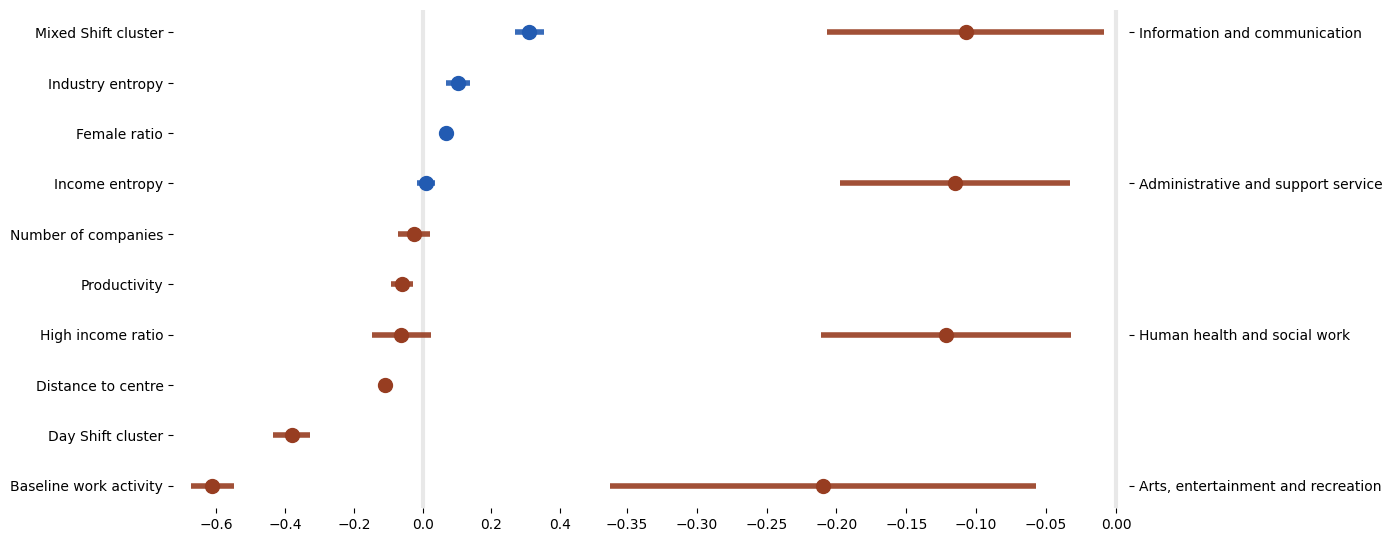

In [29]:
# Industry names
industry_names = {
    'A': 'Agriculture, forestry and fishing',
    'B': 'Mining and quarrying',
    'C': 'Manufacturing',
    'D': 'Electricity, gas, steam and air conditioning supply',
    'E': 'Water supply; sewerage, waste management',
    'F': 'Construction',
    'G': 'Wholesale and retail trade',
    'H': 'Transportation and storage',
    'I': 'Accommodation and food service activities',
    'J': 'Information and communication',
    'K': 'Financial and insurance',
    'L': 'Real estate activities',
    'M': 'Professional, scientific and technical',
    'N': 'Administrative and support service',
    'O': 'Public administration and defence',
    'P': 'Education',
    'Q': 'Human health and social work',
    'R': 'Arts, entertainment and recreation',
    'S': 'Other service activities'
}

# Base variables
base_vars = {
    "loc_work_gaussian_opening": "Baseline work activity",
    "productivity":              "Productivity",
    "n_companies":                "Number of companies",
    "entropy":                  "Industry entropy",
    "distance_to_deak":          "Distance to centre",
    "work_cluster_1[T.True]":             "Day Shift cluster",
    "work_cluster_0[T.True]":             "Mixed Shift cluster",
    "arpu_high_ratio_open":      "High income ratio",
    "income_entr_open":          "Income entropy",
    "sex_fem_ratio_open":        "Female ratio",
}

# Significant industry FEs
sig_industries = {}
for name in model_full.params.index:
    if "industry_fe" in name and model_full.pvalues[name] < 0.05:
        letter = name.split("[T.")[-1].replace("]", "")
        label = industry_names.get(letter, f"Industry {letter}")
        sig_industries[name] = label

def build_results(var_dict, model):
    df_res = pd.DataFrame({
        "coef":  model.params,
        "lower": model.conf_int()[0],
        "upper": model.conf_int()[1],
    }).loc[var_dict.keys()]
    df_res["label"] = df_res.index.map(var_dict)
    df_res["color"] = df_res["coef"].apply(lambda x: "#225bb2" if x > 0 else "#973d21")
    return df_res.sort_values("coef")

res_base = build_results(base_vars, model_full)
res_ind  = build_results(sig_industries, model_full)

# --- Layout: height driven by number of rows in each panel ---
row_height = 0.55  # inches per variable
h_base = max(2.5, len(res_base) * row_height)
h_ind  = max(2.5, len(res_ind)  * row_height)
fig_h  = max(h_base, h_ind)

fig, (ax_a, ax_b) = plt.subplots(
    1, 2,
    figsize=(14, fig_h),
    gridspec_kw={"width_ratios": [1, 1.4]}
)

def draw_coef_panel(ax, results):
    for _, row in results.iterrows():
        ax.hlines(row["label"], row["lower"], row["upper"],
                  color=row["color"], linewidth=4, alpha=0.9)
        ax.plot(row["coef"], row["label"], "o",
                color=row["color"], markersize=10)
    ax.axvline(0, color="lightgray", linestyle="-", lw=3, alpha=0.5, zorder=0)
    ax.set_ylabel("")
    ax.margins(y=0.05)
    ax.grid(False)
    sns.despine(ax=ax, left=True, bottom=True)

draw_coef_panel(ax_a, res_base)
draw_coef_panel(ax_b, res_ind)
ax_b.yaxis.set_label_position("right")
ax_b.yaxis.tick_right()

plt.tight_layout(pad=1.0)
save_figure("reg_coeffplot")
plt.show()

# Interaction with distance

In [30]:
formula_inter_fem = """
work_abs_diff ~
    income_entr_open
    + sex_fem_ratio_open
    + arpu_high_ratio_open
    + distance_to_deak:sex_fem_ratio_open
    + loc_work_gaussian_opening
    + productivity
    + n_companies
    + entropy
    + C(industry_fe, Treatment("G"))
    + distance_to_deak
    + work_cluster_1
    + work_cluster_0
"""

model_inter_fem = smf.ols(formula_inter_fem, data=df).fit(cov_type="HC3")
print(model_inter_fem.summary())

                            OLS Regression Results                            
Dep. Variable:          work_abs_diff   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     37.85
Date:                Thu, 23 Jul 2026   Prob (F-statistic):          1.95e-199
Time:                        15:56:20   Log-Likelihood:                -10575.
No. Observations:                8861   AIC:                         2.121e+04
Df Residuals:                    8831   BIC:                         2.142e+04
Df Model:                          29                                         
Covariance Type:                  HC3                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

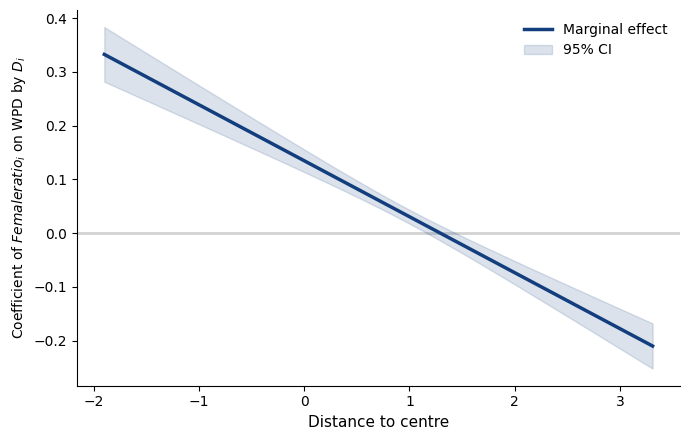

In [31]:
# Coefficient names
b_fem  = model_inter_fem.params["sex_fem_ratio_open"]
b_int  = model_inter_fem.params["distance_to_deak:sex_fem_ratio_open"]

# Variance-covariance entries for delta method
vcov       = model_inter_fem.cov_params()
var_fem    = vcov.loc["sex_fem_ratio_open",               "sex_fem_ratio_open"]
var_int    = vcov.loc["distance_to_deak:sex_fem_ratio_open", "distance_to_deak:sex_fem_ratio_open"]
cov_fem_int = vcov.loc["sex_fem_ratio_open",              "distance_to_deak:sex_fem_ratio_open"]

# --- Range of distance values to evaluate over ---
dist_range = np.linspace(df["distance_to_deak"].min(),
                         df["distance_to_deak"].max(), 100)

# --- Marginal effect and SE at each distance value ---
me   = b_fem + b_int * dist_range
se   = np.sqrt(var_fem + dist_range**2 * var_int + 2 * dist_range * cov_fem_int)
ci_lo = me - 1.96 * se
ci_hi = me + 1.96 * se

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(dist_range, me, color="#133e7e", lw=2.5, label="Marginal effect")
ax.fill_between(dist_range, ci_lo, ci_hi,
                color="#133e7e", alpha=0.15, label="95% CI")
ax.axhline(0, color="lightgray", lw=2, linestyle="-", zorder=0)

ax.set_xlabel("Distance to centre", fontsize=11)
ax.set_ylabel('Coefficient of $Female ratio_{i}$ on WPD by $D_i$', fontsize=10)
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
save_figure("fem_dist_interplot")
plt.show()

In [32]:
formula_inter_inc = """
work_abs_diff ~
    income_entr_open
    + sex_fem_ratio_open
    + arpu_high_ratio_open
    + distance_to_deak:income_entr_open
    + loc_work_gaussian_opening
    + productivity
    + n_companies
    + entropy
    + C(industry_fe, Treatment("G"))
    + distance_to_deak
    + work_cluster_1
    + work_cluster_0
"""

model_inter_low_inc = smf.ols(formula_inter_inc, data=df).fit(cov_type="HC3")
print(model_inter_low_inc.summary())

                            OLS Regression Results                            
Dep. Variable:          work_abs_diff   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     38.60
Date:                Thu, 23 Jul 2026   Prob (F-statistic):          1.51e-203
Time:                        15:56:22   Log-Likelihood:                -10600.
No. Observations:                8861   AIC:                         2.126e+04
Df Residuals:                    8831   BIC:                         2.147e+04
Df Model:                          29                                         
Covariance Type:                  HC3                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

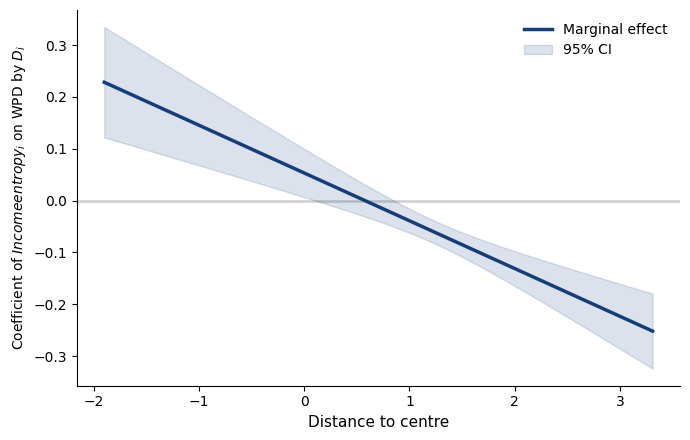

In [33]:
# Coefficient names (fixed to match this model - previously misleadingly named b_fem/var_fem
# despite being the income-interaction model)
b_inc  = model_inter_low_inc.params["income_entr_open"]
b_int  = model_inter_low_inc.params["distance_to_deak:income_entr_open"]

vcov        = model_inter_low_inc.cov_params()
var_inc     = vcov.loc["income_entr_open",               "income_entr_open"]
var_int     = vcov.loc["distance_to_deak:income_entr_open", "distance_to_deak:income_entr_open"]
cov_inc_int = vcov.loc["income_entr_open",              "distance_to_deak:income_entr_open"]

dist_range = np.linspace(df["distance_to_deak"].min(),
                         df["distance_to_deak"].max(), 100)

me   = b_inc + b_int * dist_range
se   = np.sqrt(var_inc + dist_range**2 * var_int + 2 * dist_range * cov_inc_int)
ci_lo = me - 1.96 * se
ci_hi = me + 1.96 * se

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(dist_range, me, color="#133e7e", lw=2.5, label="Marginal effect")
ax.fill_between(dist_range, ci_lo, ci_hi,
                color="#133e7e", alpha=0.15, label="95% CI")
ax.axhline(0, color="lightgray", lw=2, linestyle="-", zorder=0)

ax.set_xlabel("Distance to centre", fontsize=11)
ax.set_ylabel('Coefficient of $Income entropy_{i}$ on WPD by $D_i$', fontsize=10)
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
save_figure("income_entropy_dist_interplot")
plt.show()

# Robustness check: single-company locations

In [34]:
# Identify raster_ids with exactly one company, from the raw (unstandardized) data -
# n_companies has already been standardized in df, so filtering on == 1 must happen here
single_company_ids = df_raw.loc[df_raw["n_companies"] == 1, "raster_id"]
print(f"{len(single_company_ids)} raster_ids have exactly one company.")

df_single = df[df["raster_id"].isin(single_company_ids)].copy()

4182 raster_ids have exactly one company.


In [35]:
# drop the full industry FE and instead include indicators for specifically relevant sectors 
relevant_industries = {
    "M": "Professional, scientific and technical",
    "N": "Administrative and support service",
    "R": "Arts, entertainment and recreation",
    "Q": "Human health and social work",
    "K": "Financial and insurance",
}
for letter in relevant_industries:
    df_single[f"industry_{letter}"] = (df_single["industry_fe"] == letter).astype(int)

# Check for zero-variance regressors within this subsample before fitting - a constant
# column here would cause estimation problems (dropped/NaN coefficient)
check_cols = [f"industry_{l}" for l in relevant_industries] + ["work_cluster_1", "work_cluster_2"]
for col in check_cols:
    if df_single[col].nunique() < 2:
        print(f"Warning: '{col}' has no variation in the single-company subsample "
              f"(all values = {df_single[col].unique()}) - consider dropping it from formula_robust.")

formula_robust = """
work_abs_diff ~
    loc_work_gaussian_opening
    + productivity
    + industry_M
    + industry_N
    + industry_R
    + industry_Q
    + industry_K
    + distance_to_deak
    + work_cluster_1
    + work_cluster_0
    + arpu_high_ratio_open
    + income_entr_open
    + sex_fem_ratio_open
"""

model_robust = smf.ols(formula_robust, data=df_single).fit(cov_type="HC3")
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:          work_abs_diff   R-squared:                       0.300
Model:                            OLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     17.31
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           1.33e-39
Time:                        15:56:23   Log-Likelihood:                -3040.5
No. Observations:                4182   AIC:                             6109.
Df Residuals:                    4168   BIC:                             6198.
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

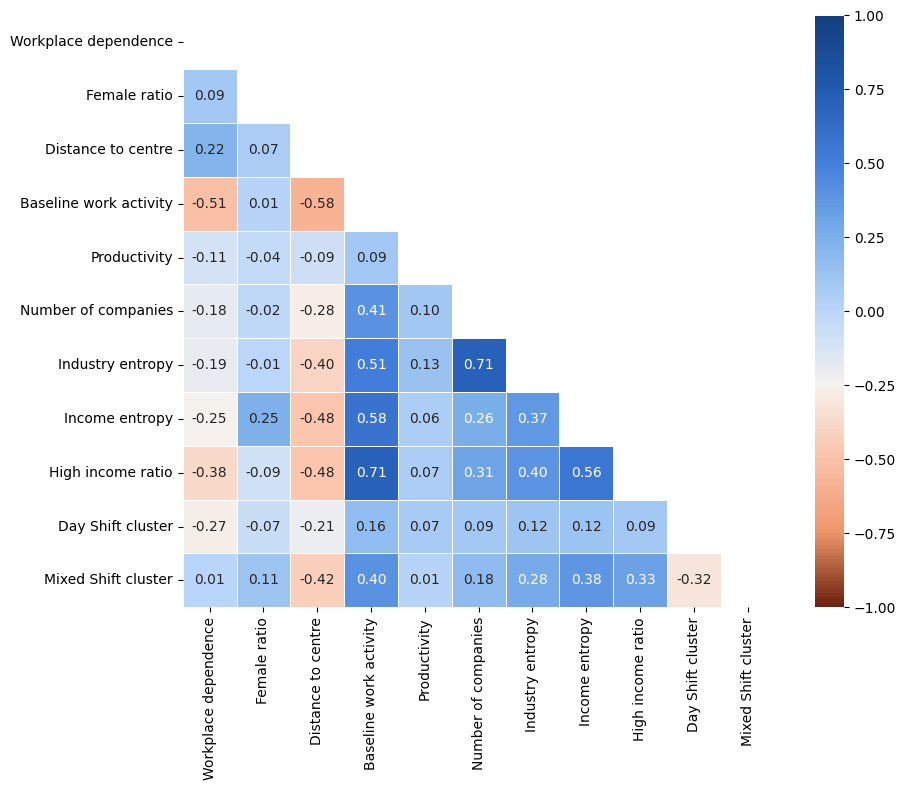

In [36]:
# List all variables in your model
model_vars = [
    "work_abs_diff",
    "sex_fem_ratio_open",
    "distance_to_deak",
    "loc_work_gaussian_opening",
    "productivity",
    "n_companies",
    "entropy",
    "income_entr_open",
    "arpu_high_ratio_open",
    "work_cluster_1",
    "work_cluster_0"
]

label_map = {
    "work_abs_diff":            "Workplace dependence",
    "sex_fem_ratio_open":       "Female ratio",
    "distance_to_deak":         "Distance to centre",
    "loc_work_gaussian_opening":"Baseline work activity",
    "productivity":             "Productivity",
    "n_companies":               "Number of companies",
    "entropy":                  "Industry entropy",
    "income_entr_open":         "Income entropy",
    "arpu_high_ratio_open":     "High income ratio",
    "work_cluster_1":            "Day Shift cluster",
    "work_cluster_0":            "Mixed Shift cluster",
}

corr = df[model_vars].corr().rename(index=label_map, columns=label_map)

# Getting the Upper Triangle of the co-relation matrix
matrix = np.triu(corr)

colors = [
   "#6b200c",  "#ee956a", "#fbc2a9",
    "#f6f2ee",
    "#bad6f9", "#7db0ea", "#447fdd", "#225bb2", "#133e7e"
]
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    mask=matrix,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

plt.tight_layout()
save_figure("corr_matrix_vars")
plt.show()

# LaTeX regression table (all OLS specifications)

In [39]:
latex_label_map = {
    "loc_work_gaussian_opening": "Baseline work activity",
    "productivity": "Productivity",
    "n_companies": "Number of companies",
    "entropy": "Industry entropy",
    "distance_to_deak": "Distance to centre",
    "work_cluster_1[T.True]": "Day Shift cluster",
    "work_cluster_0[T.True]": "Mixed Shift cluster",
    "arpu_high_ratio_open": "High income ratio",
    "income_entr_open": "Income entropy",
    "sex_fem_ratio_open": "Female ratio",
    "distance_to_deak:sex_fem_ratio_open": "DistxFemale ratio",
    "distance_to_deak:income_entr_open": "DistxIncome entropy",
}

# The robustness check's specific industry dummies
for letter, name in relevant_industries.items():
    latex_label_map[f"industry_{letter}"] = name

In [40]:
regressor_order = [
    "Intercept",
    "loc_work_gaussian_opening",
    "productivity",
    "n_companies",
    "entropy",
    "distance_to_deak",
    "work_cluster_1",
    "work_cluster_0",
    "arpu_high_ratio_open",
    "income_entr_open",
    "sex_fem_ratio_open",
    "distance_to_deak:sex_fem_ratio_open",
    "distance_to_deak:income_entr_open",
]

In [41]:
save_latex_table(
    [model_full, model_inter_fem, model_inter_low_inc, model_robust],
    model_names=["Baseline", "Female Interact", "Income Interact", "Single-company"],
    filename_stem="ols_regression_table",
    label_map=latex_label_map,
    regressor_order=regressor_order,
)

,Baseline,Female Interact,Income Interact,Single-company
Intercept,-0.0066,0.0040,-0.0461**,-0.0961***
,(0.0177),(0.0176),(0.0200),(0.0337)
loc_work_gaussian_opening,-0.6114***,-0.6248***,-0.6650***,-0.5297***
,(0.0319),(0.0314),(0.0341),(0.0657)
productivity,-0.0591***,-0.0560***,-0.0580***,-0.0162
,(0.0163),(0.0159),(0.0159),(0.0160)
n_companies,-0.0258,-0.0244,-0.0253,
,(0.0239),(0.0235),(0.0238),
entropy,0.1020***,0.1015***,0.0956***,
,(0.0179),(0.0177),(0.0176),
